In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
project_root=Path.cwd()
input_file=project_root/'mapped_data'/'MAPPED_CHURN_DATA.xlsx'

In [5]:
data=pd.read_excel(input_file)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\VASU PATEL\\OneDrive\\Desktop\\VS code\\Customer-Churn-Prediction\\EDA\\mapped_data\\MAPPED_CHURN_DATA.xlsx'

In [ ]:
data.columns

Index(['CUSTOMER_ID', 'FIRST_NAME', 'LAST_NAME', 'GENDER', 'AGE',
       'MARITAL_STATUS', 'OCCUPATION', 'DEPENDENTS', 'MONTHLY_INCOME($)',
       'INCOME_CATEGORY', 'CITY', 'STATE', 'ZIP', 'JOIN_DATE', 'TENURE_MONTHS',
       'PHONE_SERVICE', 'MULTIPLE_LINES', 'INTERNET_SERVICE',
       'ONLINE_SECURITY', 'ONLINE_BACKUP', 'DEVICE_PROTECTION', 'TECH_SUPPORT',
       'TV_STREAMING', 'MOVIE_STREAMING', 'CONTRACT', 'PAPERLESS_BILLING',
       'PAYMENT_METHOD', 'NO_OF_SERVICES', 'MONTHLY_CHARGES($)',
       'TOTAL_CHARGES($)', 'CHURN_PROBABILITY', 'CHURN'],
      dtype='str')

In [ ]:
# missing and duplicate values
print('Missing Values:')
print(data.isnull().sum())
print('Duplicate Values:')
print(data.duplicated().sum())

Missing Values:
CUSTOMER_ID           0
FIRST_NAME            0
LAST_NAME             0
GENDER                0
AGE                   0
MARITAL_STATUS        0
OCCUPATION            0
DEPENDENTS            0
MONTHLY_INCOME($)     0
INCOME_CATEGORY       0
CITY                  0
STATE                 0
ZIP                   0
JOIN_DATE             0
TENURE_MONTHS         0
PHONE_SERVICE         0
MULTIPLE_LINES        0
INTERNET_SERVICE      0
ONLINE_SECURITY       0
ONLINE_BACKUP         0
DEVICE_PROTECTION     0
TECH_SUPPORT          0
TV_STREAMING          0
MOVIE_STREAMING       0
CONTRACT              0
PAPERLESS_BILLING     0
PAYMENT_METHOD        0
NO_OF_SERVICES        0
MONTHLY_CHARGES($)    0
TOTAL_CHARGES($)      0
CHURN_PROBABILITY     0
CHURN                 0
dtype: int64
Duplicate Values:
0


In [ ]:
#pimary key columns
data['CUSTOMER_ID'].duplicated().sum()


np.int64(0)

#DATA TYPES


In [ ]:
categorical_cols = [
    'GENDER',
    'SENIOR_CITIZEN',
    'MARITAL_STATUS',
    'OCCUPATION',
    'INCOME_CATEGORY',
    'CITY',
    'STATE',
    'PHONE_SERVICE',
    'MULTIPLE_LINES',
    'INTERNET_SERVICE',
    'ONLINE_SECURITY',
    'ONLINE_BACKUP',
    'DEVICE_PROTECTION',
    'TECH_SUPPORT',
    'TV_STREAMING',
    'MOVIE_STREAMING',
    'CONTRACT',
    'PAPERLESS_BILLING',
    'PAYMENT_METHOD',
    'CHURN'
]

numeric_cols = [
    'AGE',
    'DEPENDENTS',
    'MONTHLY_INCOME($)',
    'ZIP',
    'TENURE_MONTHS',
    'MONTHLY_CHARGES($)',
    'TOTAL_CHARGES($)', 
    'CHURN_PROBABILITY',
    'NO_OF_SERVICES'
]

date_cols = [
    'JOIN_DATE'
]




In [ ]:

data['CHURN'].value_counts()

CHURN
NO     27678
YES     2322
Name: count, dtype: int64

In [ ]:
data["CHURN_PROBABILITY"].describe()


count    30000.000000
mean         0.077776
std          0.088559
min          0.020000
25%          0.020000
50%          0.038777
75%          0.100113
max          0.647939
Name: CHURN_PROBABILITY, dtype: float64

In [ ]:
data.groupby("CHURN")["CHURN_PROBABILITY"].mean()

CHURN
NO     0.068720
YES    0.185719
Name: CHURN_PROBABILITY, dtype: float64

In [ ]:
print("Probability = 2%:")
print((data["CHURN_PROBABILITY"] == 0.02).sum())

Probability = 2%:
10026


In [ ]:
print(
    data.groupby("CONTRACT")["CHURN_PROBABILITY"].mean()
)

CONTRACT
MONTH-TO-MONTH    0.112261
ONE YEAR          0.028531
TWO YEAR          0.020390
Name: CHURN_PROBABILITY, dtype: float64


In [ ]:
print(
    data.groupby("NO_OF_SERVICES")["CHURN_PROBABILITY"].mean()
)

NO_OF_SERVICES
0    0.032412
1    0.036153
2    0.061829
3    0.116730
4    0.102345
5    0.088163
6    0.070253
7    0.053816
8    0.044703
9    0.037213
Name: CHURN_PROBABILITY, dtype: float64


In [ ]:
data["TENURE_GROUP"] = pd.cut(
    data["TENURE_MONTHS"],
    bins=[0, 12, 50, float("inf")],
    labels=["<12", "12-50", ">50"]
)

print(
    data.groupby("TENURE_GROUP", observed=True)["CHURN_PROBABILITY"].mean()
)

TENURE_GROUP
<12      0.112880
12-50    0.086076
>50      0.068365
Name: CHURN_PROBABILITY, dtype: float64


In [ ]:
print(
    data.groupby("CONTRACT")["CHURN"].apply(
        lambda x: (x == "YES").mean() * 100
    )
)

CONTRACT
MONTH-TO-MONTH    11.312718
ONE YEAR           2.663633
TWO YEAR           1.752022
Name: CHURN, dtype: float64


In [ ]:
numeric_cols = data.select_dtypes(include="number").columns

print(numeric_cols)

Index(['AGE', 'DEPENDENTS', 'MONTHLY_INCOME($)', 'ZIP', 'TENURE_MONTHS',
       'NO_OF_SERVICES', 'MONTHLY_CHARGES($)', 'TOTAL_CHARGES($)',
       'CHURN_PROBABILITY'],
      dtype='str')


In [ ]:
correlation = data[numeric_cols].corr()

print(correlation)

                         AGE  DEPENDENTS  MONTHLY_INCOME($)       ZIP  \
AGE                 1.000000    0.377947           0.179587  0.004869   
DEPENDENTS          0.377947    1.000000           0.150342  0.001939   
MONTHLY_INCOME($)   0.179587    0.150342           1.000000  0.006833   
ZIP                 0.004869    0.001939           0.006833  1.000000   
TENURE_MONTHS      -0.003072   -0.001029           0.002416 -0.005148   
NO_OF_SERVICES      0.001344   -0.004498           0.000988  0.000263   
MONTHLY_CHARGES($)  0.001415   -0.004026          -0.005951  0.001109   
TOTAL_CHARGES($)   -0.000521   -0.001544          -0.003182 -0.003782   
CHURN_PROBABILITY  -0.002189   -0.015537          -0.040907 -0.010647   

                    TENURE_MONTHS  NO_OF_SERVICES  MONTHLY_CHARGES($)  \
AGE                     -0.003072        0.001344            0.001415   
DEPENDENTS              -0.001029       -0.004498           -0.004026   
MONTHLY_INCOME($)        0.002416        0.000988 

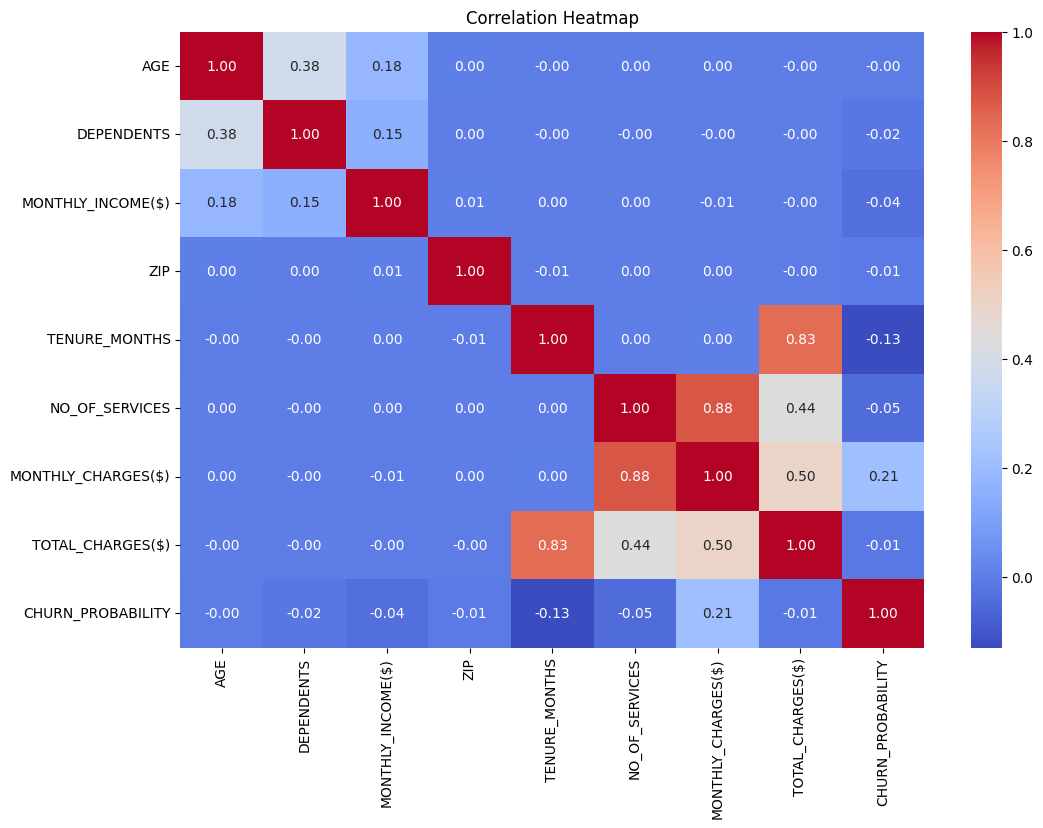

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()